In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("RetailAnalytics").getOrCreate()

In [0]:
customers_df = spark.read \
.option("header","true") \
.csv("/Volumes/pysparkazure_7405618553170348/default/practice/customers.csv")

products_df = spark.read \
.option("header","true") \
.csv("/Volumes/pysparkazure_7405618553170348/default/practice/products.csv")

orders_df = spark.read \
.option("header","true") \
.csv("/Volumes/pysparkazure_7405618553170348/default/practice/orders.csv")

preferences_df = spark.read \
.option("multiline","true") \
.json("/Volumes/pysparkazure_7405618553170348/default/practice/customer_preferences.json")
print("Customers Schema")
customers_df.printSchema()

print("Products Schema")
products_df.printSchema()

print("Orders Schema")
orders_df.printSchema()

print("Preferences Schema")
preferences_df.printSchema()

customers_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customers")

products_df.write.format("delta").mode("overwrite").saveAsTable("bronze_products")

orders_df.write.format("delta").mode("overwrite").saveAsTable("bronze_orders")

preferences_df.write.format("delta").mode("overwrite").saveAsTable("bronze_preferences")

Customers Schema
root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

Products Schema
root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: string (nullable = true)

Orders Schema
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- status: string (nullable = true)

Preferences Schema
root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df = customers_df.fillna("Unknown")

products_df = products_df.fillna("Unknown")

orders_df = orders_df.fillna("Unknown")

preferences_flat = preferences_df.select(
    "customer_id",
    "preferred_channel",
    col("loyalty.tier").alias("tier"),
    col("loyalty.points").alias("points")
)


customer_pref_df = customers_df.join(
    preferences_flat,
    "customer_id",
    "left"
)


order_customer_df = orders_df.join(
    customer_pref_df,
    "customer_id",
    "left"
)


final_df = order_customer_df.join(
    products_df,
    "product_id",
    "left"
)


final_df = final_df.withColumn(
    "quantity",
    col("quantity").cast("int")
)

final_df = final_df.withColumn(
    "unit_price",
    col("unit_price").cast("double")
)


final_df = final_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)


final_df = final_df.withColumn(
    "order_date",
    to_date("order_date")
)

final_df = final_df.withColumn(
    "order_month",
    date_format("order_date","yyyy-MM")
)


final_df = final_df.withColumn(
    "customer_segment",
    when(col("customer_type")=="Premium","High Value")
    .otherwise("Standard Value")
)


customer_pref_df.write.format("delta").mode("overwrite").saveAsTable("silver_customer_preferences")

final_df.write.format("delta").mode("overwrite").saveAsTable("silver_sales")

In [0]:
final_df.createOrReplaceTempView("sales_view")

print("Total Revenue")

spark.sql("""
SELECT SUM(revenue) AS total_revenue
FROM sales_view
""").show()

print("Revenue By City")

spark.sql("""
SELECT city,
SUM(revenue) revenue
FROM sales_view
GROUP BY city
ORDER BY revenue DESC
""").show()

print("Revenue By Category")

spark.sql("""
SELECT category,
SUM(revenue) revenue
FROM sales_view
GROUP BY category
ORDER BY revenue DESC
""").show()

print("Top Customers")

spark.sql("""
SELECT customer_name,
SUM(revenue) revenue
FROM sales_view
GROUP BY customer_name
ORDER BY revenue DESC
""").show()

print("Completed Orders")

spark.sql("""
SELECT *
FROM sales_view
WHERE status='Completed'
""").show()

Total Revenue
+-------------+
|total_revenue|
+-------------+
|     336000.0|
+-------------+

Revenue By City
+---------+--------+
|     city| revenue|
+---------+--------+
|Hyderabad|135000.0|
|    Delhi| 89000.0|
|Bangalore| 50000.0|
|   Mumbai| 21000.0|
|  Chennai| 18000.0|
|    Kochi| 15000.0|
|     Pune|  8000.0|
+---------+--------+

Revenue By Category
+-----------+--------+
|   category| revenue|
+-----------+--------+
|Electronics|250000.0|
|  Furniture| 45000.0|
|    Fashion| 41000.0|
+-----------+--------+

Top Customers
+-------------+-------+
|customer_name|revenue|
+-------------+-------+
| Rahul Sharma|90000.0|
|  Sneha Patel|89000.0|
|  Priya Reddy|50000.0|
|  Arjun Verma|45000.0|
|   Amit Kumar|21000.0|
|   Farhan Ali|18000.0|
|   Meera Nair|15000.0|
|   Neha Singh| 8000.0|
+-------------+-------+

Completed Orders
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+--------

In [0]:
product_revenue = final_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

window1 = Window.orderBy(desc("revenue"))

product_rank = product_revenue.withColumn(
    "rank",
    rank().over(window1)
)

product_rank.show()

customer_revenue = final_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("revenue")
)

window2 = Window.orderBy(desc("revenue"))

customer_rank = customer_revenue.withColumn(
    "rank",
    rank().over(window2)
)

customer_rank.show()

print("Top 3 Customers")

customer_rank.filter(
    col("rank") <= 3
).show()

category_revenue = final_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("revenue")
)

window3 = Window.partitionBy(
    "category"
).orderBy(desc("revenue"))

top_product_category = category_revenue.withColumn(
    "rank",
    rank().over(window3)
).filter(
    col("rank")==1
)

top_product_category.show()

daily_revenue = final_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("daily_revenue")
)

window4 = Window.orderBy("order_date")

running_revenue = daily_revenue.withColumn(
    "running_revenue",
    sum("daily_revenue").over(window4)
)

running_revenue.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+--------+----+
|product_name| revenue|rank|
+------------+--------+----+
|      Laptop|130000.0|   1|
|      Mobile| 75000.0|   2|
|          TV| 45000.0|   3|
|       Table| 24000.0|   4|
|       Chair| 21000.0|   5|
|       Shoes| 18000.0|   6|
|         Bag| 15000.0|   7|
|       Watch|  8000.0|   8|
+------------+--------+----+

+-------------+-------+----+
|customer_name|revenue|rank|
+-------------+-------+----+
| Rahul Sharma|90000.0|   1|
|  Sneha Patel|89000.0|   2|
|  Priya Reddy|50000.0|   3|
|  Arjun Verma|45000.0|   4|
|   Amit Kumar|21000.0|   5|
|   Farhan Ali|18000.0|   6|
|   Meera Nair|15000.0|   7|
|   Neha Singh| 8000.0|   8|
+-------------+-------+----+

Top 3 Customers
+-------------+-------+----+
|customer_name|revenue|rank|
+-------------+-------+----+
| Rahul Sharma|90000.0|   1|
|  Sneha Patel|89000.0|   2|
|  Priya Reddy|50000.0|   3|
+-------------+-------+----+

+-----------+------------+--------+----+
|   category|product_name| revenue|rank|


In [0]:
final_df.write.format("delta").mode("overwrite").save("/tmp/delta_sales")

final_df.write.format("delta").mode("overwrite").saveAsTable("delta_sales_table")

spark.sql("""
CREATE TABLE IF NOT EXISTS delta_sales_sql
USING DELTA
AS
SELECT * FROM silver_sales
""")

spark.sql("""
DESCRIBE HISTORY delta_sales_table
""").show(truncate=False)


spark.read.format("delta")\
.option("versionAsOf",0)\
.table("delta_sales_table")\
.show()


updated_customer = spark.createDataFrame(
[
("C101","Rahul Sharma Updated","Hyderabad","Telangana","Premium")
],
[
"customer_id",
"customer_name",
"city",
"state",
"customer_type"
]
)

updated_customer.createOrReplaceTempView("updated_customer")

spark.sql("""
MERGE INTO bronze_customers target
USING updated_customer source
ON target.customer_id = source.customer_id

WHEN MATCHED THEN
UPDATE SET
target.customer_name = source.customer_name,
target.city = source.city,
target.state = source.state,
target.customer_type = source.customer_type
""")

spark.sql("""
DESCRIBE HISTORY bronze_customers
""").show(truncate=False)

spark.sql("""
OPTIMIZE delta_sales_table
""")

spark.sql("""
OPTIMIZE delta_sales_table
ZORDER BY (city)
""")

spark.sql("""
VACUUM delta_sales_table RETAIN 168 HOURS
""")

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                                

DataFrame[path: string]

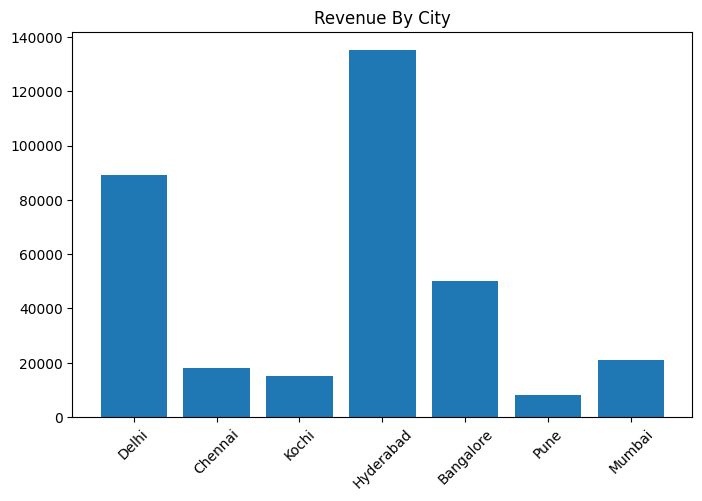

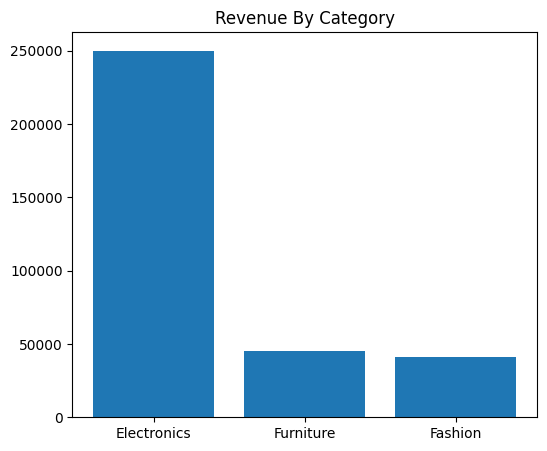

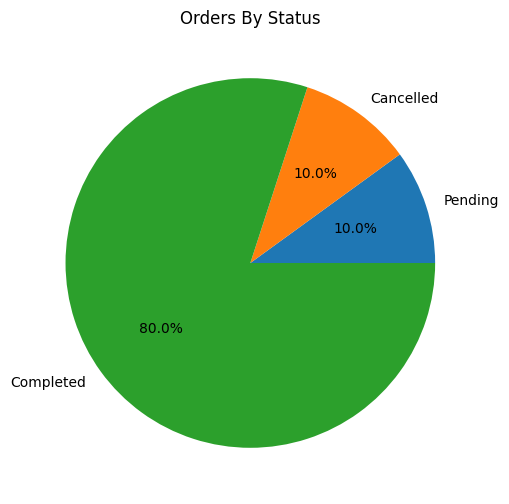

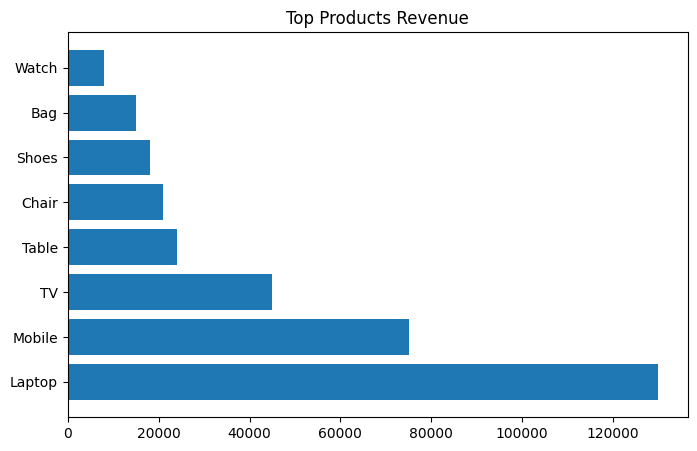

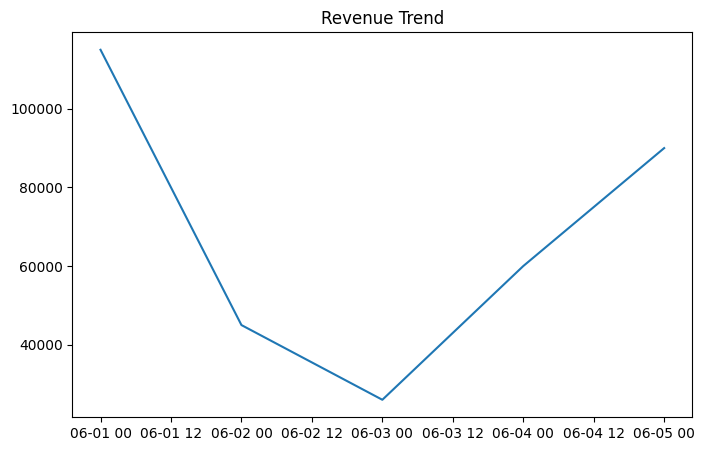

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

city_df = final_df.groupBy("city")\
.agg(sum("revenue").alias("revenue"))\
.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_df["city"],city_df["revenue"])
plt.title("Revenue By City")
plt.xticks(rotation=45)
plt.show()

category_df = final_df.groupBy("category")\
.agg(sum("revenue").alias("revenue"))\
.toPandas()

plt.figure(figsize=(6,5))
plt.bar(category_df["category"],category_df["revenue"])
plt.title("Revenue By Category")
plt.show()


status_df = final_df.groupBy("status")\
.count()\
.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_df["count"],
    labels=status_df["status"],
    autopct="%1.1f%%"
)
plt.title("Orders By Status")
plt.show()


top_product = final_df.groupBy("product_name")\
.agg(sum("revenue").alias("revenue"))\
.orderBy(desc("revenue"))\
.toPandas()

plt.figure(figsize=(8,5))
plt.barh(top_product["product_name"],top_product["revenue"])
plt.title("Top Products Revenue")
plt.show()


trend_df = final_df.groupBy("order_date")\
.agg(sum("revenue").alias("revenue"))\
.orderBy("order_date")\
.toPandas()

plt.figure(figsize=(8,5))
plt.plot(trend_df["order_date"],trend_df["revenue"])
plt.title("Revenue Trend")
plt.show()

In [0]:

final_df.write.mode("overwrite").saveAsTable("managed_sales")



final_df.write.format("delta") \
.mode("overwrite") \
.save("/Volumes/pysparkazure_7405618553170348/default/practice/external_sales")

external_df = spark.read.format("delta").load(
"/Volumes/pysparkazure_7405618553170348/default/practice/external_sales"
)

external_df.show()


final_df.createOrReplaceTempView("temp_sales_view")


final_df.createOrReplaceTempView("global_sales_view")

print("Managed Table : Stored in Databricks managed location")
print("External Table : Data stored outside metastore")
print("Temporary View : Session scope")
print("Global Temporary View : Accessible across sessions")
print("Database name = global_temp.global_sales_view")

print("CAPSTONE PROJECT COMPLETED SUCCESSFULLY")

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Laptop|Electronics|   65000.0|65000.0|    2026-06|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|   